In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler,RobustScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


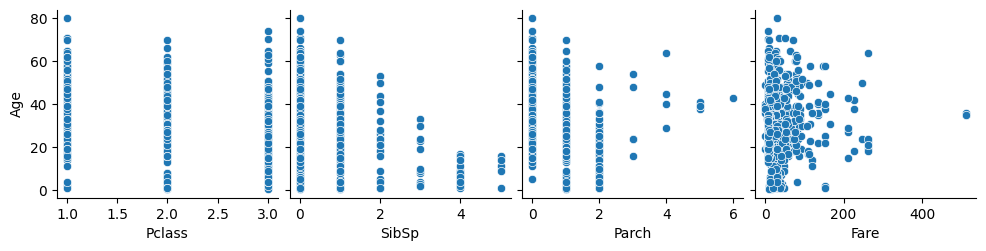

In [2]:
df = pd.read_csv("train.csv")
df.info()

top_features = ['Pclass', 'SibSp', 'Parch', 'Fare', ]
sns.pairplot(df, x_vars=top_features, y_vars='Age', kind='scatter')
plt.show()

In [3]:
mode = df.loc[df['Embarked'].notna(), 'Embarked'].mode()[0]
print(mode)
def pre_process(df):
    df['Embarked'] = df['Embarked'].fillna(mode)
    df['embarked'] = df['Embarked'].map({'Q': 1, 'S': 2, 'C': 3})

    # Encode Sex
    df['title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    # df['title'] = df['title'].fillna('Unknown')
    df['title_num'] = pd.factorize(df['title'])[0] + 1
    df['cabin_num'] = df['Cabin'].str.extract('([A-Za-z])', expand=False).astype('category').cat.codes
    df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

    # Drop unused columns
    df.drop(columns=['Name', 'Cabin', 'Embarked', 'title'], inplace=True)
    df['Ticket'] = df['Ticket'].astype('category').cat.codes
    df['Fare_per_person'] = df['Fare'] / (df['Family_Size'])
    df['isAlone'] = (df['Family_Size'] == 1).astype(int)

    return df

df = pre_process(df)
print(df.info())

def preprocess(df):
    df1 = df.copy()

    train = df1[df1['Age'].notna()].copy()
    test = df1[df1['Age'].isna()].copy()

    Y = train['Age']
    X = train.drop(columns=['Age'])
    if 'Survived' in X.columns:
        X = X.drop(columns=['Survived'])

    pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('regressor', LinearRegression())
    ])

    param_grid = {
        'scaler': [StandardScaler(), RobustScaler()],
        'regressor__fit_intercept': [True, False]
    }

    grid_search2 = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1, verbose=1)
    grid_search2.fit(X, Y)
    print("Best parameters:", grid_search2.best_params_)
    print("Best score:", grid_search2.best_score_)

    X_test = test.drop(columns=['Age'])
    if 'Survived' in X_test.columns:
        X_test = X_test.drop(columns=['Survived'])
    predicted_ages = grid_search2.predict(X_test)

    df1.loc[df1['Age'].isna(), 'Age'] = predicted_ages
    df1['Fare_per_person'] = df1['Fare'] / (df1['Family_Size'])
    return df1

df = preprocess(df)
df.drop(columns=['PassengerId'], inplace=True)



S
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Sex              891 non-null    int64  
 4   Age              714 non-null    float64
 5   SibSp            891 non-null    int64  
 6   Parch            891 non-null    int64  
 7   Ticket           891 non-null    int16  
 8   Fare             891 non-null    float64
 9   embarked         891 non-null    int64  
 10  title_num        891 non-null    int64  
 11  cabin_num        891 non-null    int8   
 12  Family_Size      891 non-null    int64  
 13  Fare_per_person  891 non-null    float64
 14  isAlone          891 non-null    int32  
dtypes: float64(3), int16(1), int32(1), int64(9), int8(1)
memory usage: 89.8 KB
None
Fitting 3 folds for each o

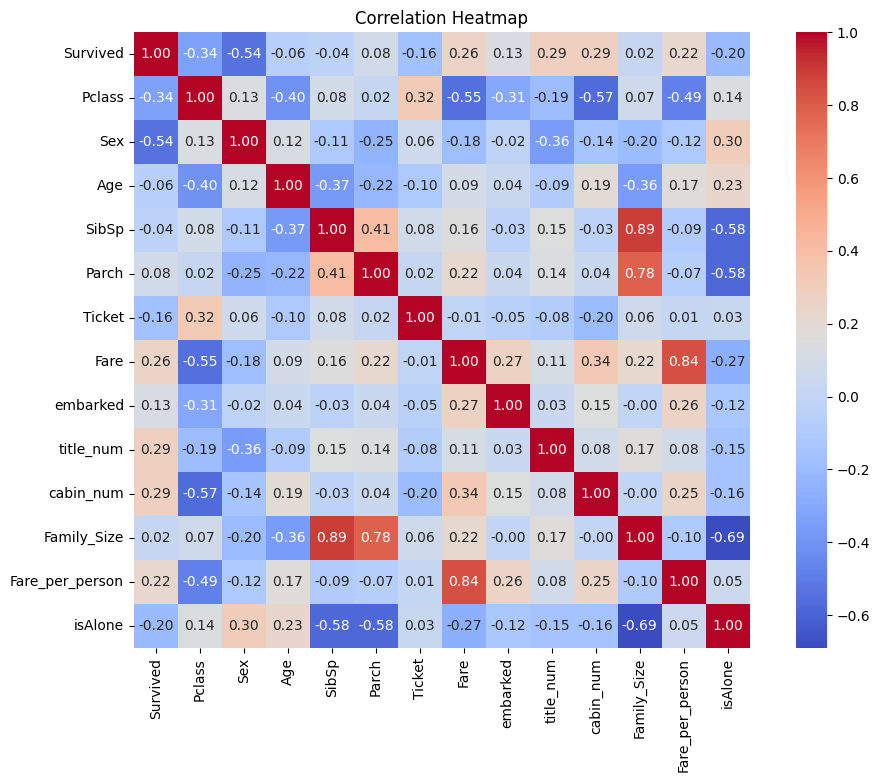

In [4]:
corr = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Heatmap")
plt.show()

Y = df['Survived']
X = df.drop(columns=['Survived'])

In [ ]:
pipeline1 = Pipeline([
    ('scaler', StandardScaler()), 
    ('classifier', LogisticRegression(max_iter=100000, random_state=42, n_jobs=-1))
])

param_grid = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2', 'elasticnet'],
    'classifier__solver': ['saga'],
    'classifier__l1_ratio': [0, 0.25, 0.5, 0.75, 1]
}

grid_search1 = GridSearchCV(pipeline1, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search1.fit(X, Y)

x = grid_search1.best_score_
# print(type(x))
print("Best parameters:", grid_search1.best_params_)
print("Best score:", grid_search1.best_score_)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits
Best parameters: {'classifier__C': 10, 'classifier__l1_ratio': 0, 'classifier__penalty': 'l1', 'classifier__solver': 'saga', 'scaler': MinMaxScaler()}
Best score: 0.8019107652910471


c:\Users\shari\miniconda3\envs\python3\Lib\site-packages\sklearn\linear_model\_logistic.py:1172: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


In [ ]:
pipeline2 = Pipeline([
    ('scaler', StandardScaler()), 
    ('classifier', RandomForestClassifier())
])

param_grid2 = {
    'scaler': [StandardScaler(), RobustScaler()],
    'classifier__n_estimators': [300, 500, 800],
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': [None, 'sqrt', 'log2'],
}

grid_search2 = GridSearchCV(pipeline2, param_grid2, cv=3, n_jobs=-1, verbose=1)
grid_search2.fit(X, Y)
y = grid_search2.best_score_
print("Best parameters:", grid_search2.best_params_)
print("Best score:", grid_search2.best_score_)

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__max_features': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300, 'scaler': StandardScaler()}
Best score: 0.8455365268470256


In [ ]:
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBClassifier(
        device='cuda',
        use_label_encoder=False,
        eval_metric='rmse'
    ))
])

xgb_param_grid = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'classifier__n_estimators': [400, 500],
    'classifier__max_depth': [6, 8, 10, 12],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.6, 0.8],
    'classifier__colsample_bytree': [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(xgb_pipeline, xgb_param_grid, cv=2, n_jobs=-1, verbose=1)
xgb_grid_search.fit(X, Y)
z = xgb_grid_search.best_score_
print("XGBoost Best parameters:", xgb_grid_search.best_params_)
print("XGBoost Best score:", xgb_grid_search.best_score_)

Fitting 2 folds for each of 192 candidates, totalling 384 fits


c:\Users\shari\miniconda3\envs\python3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\shari\miniconda3\envs\python3\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:06:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Best parameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 6, 'classifier__n_estimators': 400, 'classifier__subsample': 0.8, 'scaler': StandardScaler()}
XGBoost Best score: 0.8202247191011236


In [ ]:
pipeline3 = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(probability=True))
])

grid_param3 = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'classifier__C': [0.1, 1, 8, 10, 12, 14],
    'classifier__gamma': [0.01, 0.1, 1],
    'classifier__kernel': ['linear', 'rbf']
}

grid_search3 = GridSearchCV(pipeline3, grid_param3, cv=3, n_jobs=-1, verbose=1)
grid_search3.fit(X, Y)
xx = grid_search3.best_score_
print("SVC Best parameters:", grid_search3.best_params_)
print("SVC Best score:", grid_search3.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
SVC Best parameters: {'classifier__C': 1, 'classifier__gamma': 1, 'classifier__kernel': 'rbf', 'scaler': MinMaxScaler()}
SVC Best score: 0.8202259806876336


In [59]:
df1 = pd.read_csv("test.csv")
df2 = df1.copy()
df1 = pre_process(df1)
for pclass in df1['Pclass'].unique():
    mask = df1['Fare'].isna() & (df1['Pclass'] == pclass)
    med = df.loc[df['Fare'].notna() & (df['Pclass'] == pclass), 'Fare_per_person'].mean()
    df1.loc[mask, 'Fare'] = med * df1.loc[mask, 'Family_Size']
    df1.loc[mask, 'Fare_per_person'] = med


# df1.info()

df1 = preprocess(df1)
df1.drop(columns=['PassengerId'], inplace=True)
predictions1 = grid_search1.predict(df1).astype(float)
predictions2 = grid_search2.predict(df1).astype(float)
predictions3 = xgb_grid_search.predict(df1).astype(float)
predictions4 = grid_search3.predict(df1).astype(float)

# print(type((int)x))
to = y + xx + z + x
weighted_preds = (predictions2 * y + predictions4 * xx + predictions3 * z + predictions1 * x) / to

final_predictions = (weighted_preds >= 0.5).astype(int)

# Prepare submission
submission = pd.DataFrame({
    "PassengerId": df2["PassengerId"],
    "Survived": final_predictions
})

submission.to_csv("submission.csv", index=False)
print(submission)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters: {'regressor__fit_intercept': True, 'scaler': StandardScaler()}
Best score: 0.25594699227380946
     PassengerId  Survived
0            892         0
1            893         1
2            894         0
3            895         0
4            896         1
..           ...       ...
413         1305         0
414         1306         1
415         1307         0
416         1308         0
417         1309         1

[418 rows x 2 columns]
